# StrokeDetector — Demo Inference

This notebook demonstrates end-to-end inference on a single ISLES-2022 case.

**Requirements:**
- ISLES-2022 dataset downloaded locally (register at https://isles-22.grand-challenge.org/)
- Stage 3 checkpoint downloaded (see README for download instructions)
- Package installed: `pip install -e ..` from the repo root

**Runtime:** approximately 10–30 seconds on GPU, 1–2 minutes on CPU.

## 1. Configuration

Edit these paths to match your local setup.

In [2]:
import sys
import json
import subprocess
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Add repo root to path if package not installed
sys.path.insert(0, str(Path('..').resolve()))

# ── USER: set these paths ──────────────────────────────────────────────
ISLES_ROOT = Path('E:/Stroke/ISLES-2022')
CHECKPOINT = Path('E:/Stroke/checkpoints_stage3/stage3_best.pt')
OUT_DIR     = Path('./demo_output')

# This case has a large clear lesion — good for demonstration
# Replace with any ISLES-2022 subject ID
SUBJECT = 'sub-strokecase0221'
SES     = 'ses-0001'
# ──────────────────────────────────────────────────────────────────────

dwi_path = ISLES_ROOT / SUBJECT / SES / 'dwi' / f'{SUBJECT}_{SES}_dwi.nii.gz'
adc_path = ISLES_ROOT / SUBJECT / SES / 'dwi' / f'{SUBJECT}_{SES}_adc.nii.gz'

# Verify paths exist
assert ISLES_ROOT.exists(), f'ISLES-2022 not found at: {ISLES_ROOT}\nEdit ISLES_ROOT above.'
assert dwi_path.exists(),   f'DWI not found: {dwi_path}'
assert adc_path.exists(),   f'ADC not found: {adc_path}'
assert CHECKPOINT.exists(), f'Checkpoint not found: {CHECKPOINT}\nSee README for download instructions.'

OUT_DIR.mkdir(exist_ok=True)
print(f'DWI:        {dwi_path}')
print(f'ADC:        {adc_path}')
print(f'Checkpoint: {CHECKPOINT}')
print(f'Output:     {OUT_DIR}')
print('All paths OK')

DWI:        E:\Stroke\ISLES-2022\sub-strokecase0221\ses-0001\dwi\sub-strokecase0221_ses-0001_dwi.nii.gz
ADC:        E:\Stroke\ISLES-2022\sub-strokecase0221\ses-0001\dwi\sub-strokecase0221_ses-0001_adc.nii.gz
Checkpoint: E:\Stroke\checkpoints_stage3\stage3_best.pt
Output:     demo_output
All paths OK


## 2. Run Inference

In [3]:
cmd = [
    sys.executable,
    str(Path('..') / 'scripts' / 'localize_stroke.py'),
    '--dwi',        str(dwi_path),
    '--adc',        str(adc_path),
    '--checkpoint', str(CHECKPOINT),
    '--out_dir',    str(OUT_DIR),
    '--subject',    SUBJECT,
]

print('Running inference...')
proc = subprocess.run(cmd, capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print('STDERR:', proc.stderr)

Running inference...

[INFO] Subject : sub-strokecase0221
[INFO] Device  : cpu

[STEP 1] Loading DWI: E:\Stroke\ISLES-2022\sub-strokecase0221\ses-0001\dwi\sub-strokecase0221_ses-0001_dwi.nii.gz
[INFO] DWI shape: (112, 112, 73)  vox: (2.0, 2.0, 2.0)
[INFO] DWI already 3D

[STEP 2] Loading ADC: E:\Stroke\ISLES-2022\sub-strokecase0221\ses-0001\dwi\sub-strokecase0221_ses-0001_adc.nii.gz
[INFO] ADC shape: (112, 112, 73)  vox: (2.0, 2.0, 2.0)

[STEP 3] Preprocessing to model space [96, 96, 64] @ [1.5, 1.5, 3.0]mm  (CoM crop)...
[INFO] Model input: (1, 2, 64, 96, 96)

[STEP 4] Loading model: E:\Stroke\checkpoints_stage3\stage3_best.pt
[INFO] stage=3  epoch=1  val_mAP=0.8690  params=0.504M

[STEP 5] Detecting stroke...

RESULT — sub-strokecase0221
  has_lesion   : True
  confidence   : 0.9999
  seg_vol_ml   : 86.454 ml
  subtype      : focal
  center (model): (np.float64(32.9), np.float64(34.5), np.float64(21.5))
  modalities   : DWI+ADC

[INFO] b1000 native volume saved: demo_output\b1000_nat

## 3. Load and Print Result JSON

In [5]:
result_path = OUT_DIR / 'result.json'
assert result_path.exists(), f'Result not found: {result_path}'

with open(result_path) as f:
    result = json.load(f)

print(json.dumps(result, indent=2))

{
  "subject": "sub-strokecase0221",
  "has_lesion": true,
  "presence_conf": 0.5228,
  "confidence": 0.9999,
  "seg_volume_ml": 86.454,
  "center_model": [
    32.9,
    34.5,
    21.5
  ],
  "box_model": [
    8.8,
    10.0,
    9.0,
    57.0,
    59.0,
    34.0
  ],
  "subtype": 0,
  "subtype_str": "focal",
  "modalities": "DWI+ADC",
  "model_shape": [
    96,
    96,
    64
  ],
  "spacing_mm": [
    1.5,
    1.5,
    3.0
  ],
  "stroke_volumes": {
    "stroke_volume_dwi_ml": 88.152,
    "stroke_volume_adc_ml": 88.152,
    "stroke_volume_combined_ml": 88.152,
    "stroke_volume_intersection_ml": 88.152,
    "stroke_volume_union_ml": 88.152
  },
  "thresholds": {
    "score_thresh": 0.3,
    "min_seg_volume_ml": 0.15
  }
}


## 4. Visualise — DWI with Segmentation Overlay

In [7]:
# Load DWI and segmentation mask (native space)
dwi_img  = nib.load(str(dwi_path))
dwi_data = dwi_img.get_fdata(dtype=np.float32)

mask_path = OUT_DIR / 'seg_mask_native.nii.gz'
mask_img  = nib.load(str(mask_path))
mask_data = mask_img.get_fdata(dtype=np.float32)

print(f'DWI shape:  {dwi_data.shape}')
print(f'Mask shape: {mask_data.shape}')
print(f'Mask nonzero voxels: {int((mask_data > 0).sum())}')

DWI shape:  (112, 112, 73)
Mask shape: (112, 112, 73)
Mask nonzero voxels: 11019


Displaying axial slice z = 21


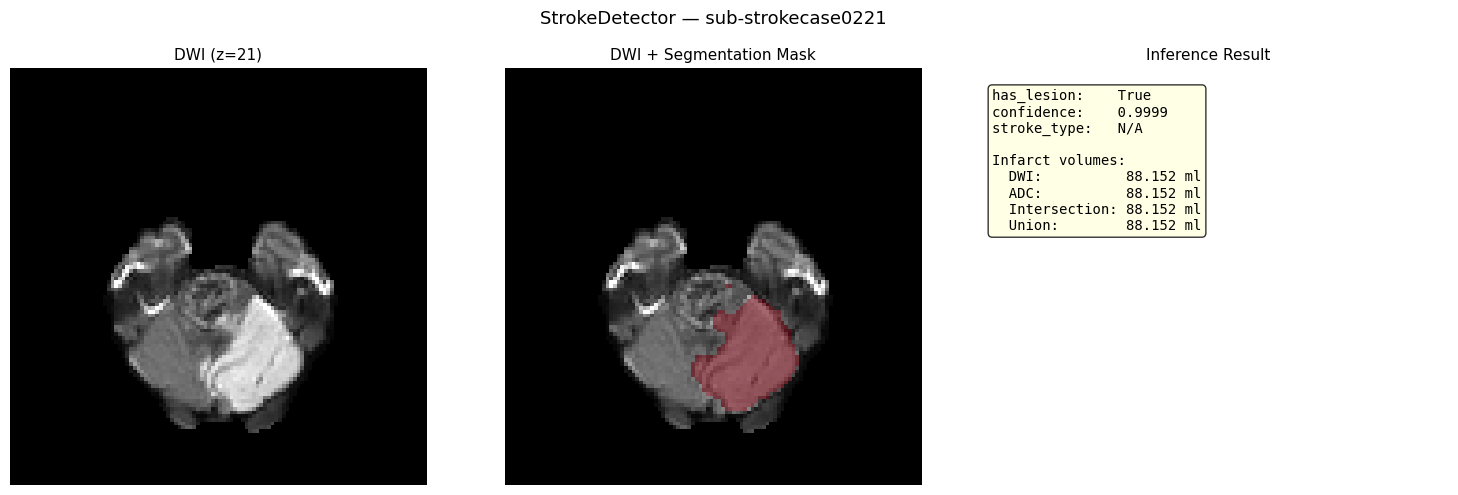

Saved: demo_output\sub-strokecase0221_visualisation.png


In [8]:
# Find the axial slice with the most lesion voxels
if mask_data.sum() > 0:
    lesion_per_slice = mask_data.sum(axis=(0, 1))
    best_z = int(lesion_per_slice.argmax())
else:
    best_z = dwi_data.shape[2] // 2
    print('No lesion detected — showing middle slice')

print(f'Displaying axial slice z = {best_z}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'StrokeDetector — {SUBJECT}', fontsize=13)

# DWI
dwi_sl = dwi_data[:, :, best_z]
vmax   = float(np.percentile(dwi_sl[dwi_sl > 0], 99)) if (dwi_sl > 0).any() else 1.
axes[0].imshow(dwi_sl.T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
axes[0].set_title(f'DWI (z={best_z})', fontsize=11)
axes[0].axis('off')

# DWI + segmentation overlay
axes[1].imshow(dwi_sl.T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
mask_sl = mask_data[:, :, best_z]
masked  = np.ma.masked_where(mask_sl.T < 0.5, mask_sl.T)
axes[1].imshow(masked, cmap='Reds', alpha=0.6, origin='lower', vmin=0, vmax=1)
axes[1].set_title('DWI + Segmentation Mask', fontsize=11)
axes[1].axis('off')

# Result summary text
axes[2].axis('off')
vols = result.get('stroke_volumes', {})
lines = [
    f"has_lesion:    {result.get('has_lesion', 'N/A')}",
    f"confidence:    {result.get('confidence', 'N/A')}",
    f"stroke_type:   {result.get('stroke_type', 'N/A')}",
    "",
    "Infarct volumes:",
    f"  DWI:          {vols.get('stroke_volume_dwi_ml', 'N/A')} ml",
    f"  ADC:          {vols.get('stroke_volume_adc_ml', 'N/A')} ml",
    f"  Intersection: {vols.get('stroke_volume_intersection_ml', 'N/A')} ml",
    f"  Union:        {vols.get('stroke_volume_union_ml', 'N/A')} ml",
]
axes[2].text(
    0.05, 0.95, '\n'.join(lines),
    transform=axes[2].transAxes,
    fontsize=10, verticalalignment='top', fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
axes[2].set_title('Inference Result', fontsize=11)

plt.tight_layout()
out_fig = OUT_DIR / f'{SUBJECT}_visualisation.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

## Notes

- The segmentation mask is in **native image space** — same shape and affine as the input DWI.
- `stroke_type` values: `positive_single`, `positive_multi`, `embolic`, `negative`
- `has_lesion` uses a two-signal gate: `confidence >= 0.3 AND seg_volume >= 0.15 ml`
- **Limitation:** Specificity is 0.200 on the ISLES-2022 test set. All results require radiologist review.
- Replace `sub-strokecase0221` with any subject ID from your ISLES-2022 download.